In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [36]:
pd.set_option('display.max_columns', None)

In [2]:
data  = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/TenisCSV.csv'

In [4]:
df = pd.read_csv(data)

In [12]:
df.shape

(16085, 36)

In [6]:
df.head(5)

,Unnamed: 0,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,...,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL
0,0,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,...,0.0,Completed,1.11,6.50,1.13,7.41,1.15,7.54,1.12,6.12
1,1,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,...,0.0,Retired,2.25,1.57,2.27,1.71,2.30,1.75,2.21,1.64
2,2,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,...,0.0,Completed,1.04,13.00,1.04,16.00,1.06,16.00,1.04,11.54
3,3,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,...,0.0,Completed,1.44,2.62,1.42,3.11,1.50,3.11,1.45,2.70
4,4,33.0,Paris,French Open,24/05/15,Grand Slam,Outdoor,Clay,1st Round,5.0,...,0.0,Completed,2.00,1.72,2.11,1.81,2.11,1.85,2.00,1.78


In [8]:
df = df.drop(columns=['Unnamed: 0'])

Eliminamos filas que son todas nulas

In [13]:
df = df.dropna(how='all')

Eliminamos filas que tienen nulo al Winner o Loser

In [30]:
df = df.dropna(subset=['Winner', 'Loser'])

Cuando no conocemos el ranking del perdedor, deberemos imputar por el ultimo registro, porque se da de manera aleatoria y no quisiera perder esos partidos

In [37]:
df[df['LRank'].isna() == True]

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,Loser,WRank,LRank,WPts,LPts,W1,L1,W2,L2,W3,L3,W4,L4,W5,L5,Wsets,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL
308,33.0,Paris,French Open,30/05/17,Grand Slam,Outdoor,Clay,1st Round,5.0,Nishikori K.,Kokkinakis T.,9.0,NaN,3650.0,NaN,4.0,6.0,6.0,1.0,6.0,4.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,1.020,17.00,1.03,17.65,1.03,18.50,1.02,14.08
565,32.0,Paris,French Open,28/05/2019,Grand Slam,Outdoor,Clay,1st Round,5.0,Khachanov K.,Stebe C.M.,11.0,NaN,2800.0,NaN,6.0,1.0,6.0,1.0,6.0,4.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.040,13.00,1.05,13.87,1.06,15.25,1.04,12.38
2453,51.0,New York,US Open,29/08/2023,Grand Slam,Outdoor,Hard,1st Round,5.0,Medvedev D.,Balazs A.,3.0,NaN,6260.0,NaN,6.0,1.0,6.0,1.0,6.0,0.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.000,67.00,1.01,64.19,1.01,67.00,1.01,34.68
2976,6.0,Melbourne,Australian Open,19/01/16,Grand Slam,Outdoor,Hard,1st Round,5.0,Bolelli S.,Baker B.,64.0,NaN,765.0,NaN,7.0,6.0,7.0,6.0,6.0,7.0,7.0,6.0,NaN,NaN,3.0,1.0,Completed,1.100,7.00,1.13,7.04,1.13,8.00,1.10,6.89
2984,6.0,Melbourne,Australian Open,19/01/16,Grand Slam,Outdoor,Hard,1st Round,5.0,Wawrinka S.,Tursunov D.,4.0,NaN,6865.0,NaN,7.0,6.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Retired,1.010,26.00,1.01,34.00,1.02,34.00,1.01,19.84
3106,6.0,Melbourne,Australian Open,17/01/17,Grand Slam,Outdoor,Hard,1st Round,5.0,Paire B.,Haas T.,47.0,NaN,960.0,NaN,7.0,6.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,Retired,1.220,4.33,1.27,4.22,1.27,4.50,1.22,4.16
3310,6.0,Melbourne,Australian Open,14/01/2019,Grand Slam,Outdoor,Hard,1st Round,5.0,Dimitrov G.,Tipsarevic J.,21.0,NaN,1790.0,NaN,4.0,6.0,6.0,3.0,6.0,1.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,1.060,10.00,1.08,10.26,1.08,13.00,1.06,9.97
3479,4.0,Melbourne,Australian Open,21/01/2020,Grand Slam,Outdoor,Hard,1st Round,5.0,Monfils G.,Lu Y.H.,10.0,NaN,2565.0,NaN,6.0,1.0,6.0,4.0,6.0,2.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.010,21.00,1.02,24.40,1.03,29.00,1.02,18.31
3604,5.0,Melbourne,Australian Open,09/02/2021,Grand Slam,Outdoor,Hard,1st Round,5.0,Lopez F.,Tu L.,65.0,NaN,998.0,NaN,6.0,7.0,6.0,4.0,7.0,6.0,6.0,4.0,NaN,NaN,3.0,1.0,Completed,1.330,3.40,1.34,3.63,1.37,3.71,1.33,3.35
3890,5.0,Melbourne,Australian Open,19/01/2023,Grand Slam,Outdoor,Hard,2nd Round,5.0,Evans D.,Chardy J.,30.0,NaN,1380.0,NaN,6.0,4.0,6.0,4.0,6.0,1.0,NaN,NaN,NaN,NaN,3.0,0.0,Completed,1.130,6.00,1.13,7.49,1.19,7.49,1.12,6.27


Las distribuciones de B365 odds y Average Odds no son iguales

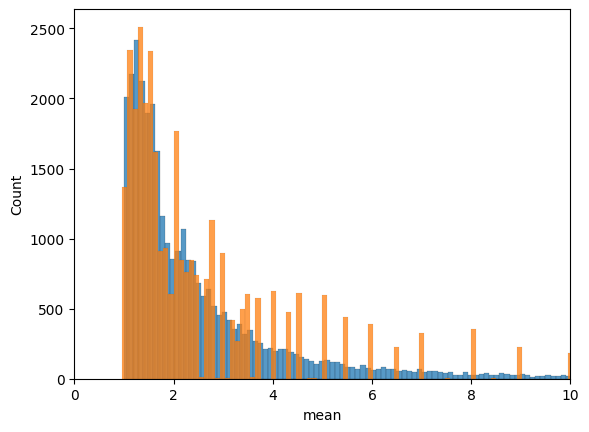

TEST 1 - KS2
Con p-valor 2.1996571606898886e-08, podemos rechazar la hipótesis nula de que las distribuciones son iguales
TEST 2 KS2- REDUCIDO
Con p-valor 2.0254178514804353e-09, podemos rechazar la hipótesis nula de que las distribuciones son iguales
TEST 3 - Mann-Whitney U
Con p-valor 0.2749472136016379, se retiene la hipótesis nula de que las distribuciones y medianas son iguales
TEST 4 - Correlacion
p-Valor Pearson: 0.0
p-Valor Spearman:0.0


In [76]:
df_copia = df.copy()
df_copia = df_copia.dropna(subset=['AvgW', 'AvgL', 'B365W', 'B365L'])
mean_odds = pd.concat([df_copia['AvgW'], df_copia['AvgL']], axis=0)
b365_odds = pd.concat([df_copia['B365W'], df_copia['B365L']], axis=0)
df_odds = pd.concat([mean_odds, b365_odds], axis=1, keys=['mean','b365'])
sns.histplot(data=df_odds['mean'])
sns.histplot(data=df_odds['b365'])
plt.xlim(0, 10)
plt.show()

print('TEST 1 - KS2')
ks2 = stats.ks_2samp(df_odds['mean'],df_odds['b365'])
if ks2.pvalue<0.05:
  print(f'Con p-valor {ks2.pvalue}, podemos rechazar la hipótesis nula de que las distribuciones son iguales')
else:
  print(f'Con p-valor {ks2.pvalue}, se retiene la hipótesis nula de que las distribuciones son iguales')

print('TEST 2 KS2- REDUCIDO')
odds_reduced = df_odds.copy()
odds_reduced = odds_reduced[(odds_reduced['mean'] < 5) & (odds_reduced['b365'] < 5)]
ks2_2 = stats.ks_2samp(odds_reduced['mean'],odds_reduced['b365'])
if ks2_2.pvalue<0.05:
  print(f'Con p-valor {ks2_2.pvalue}, podemos rechazar la hipótesis nula de que las distribuciones son iguales')
else:
  print(f'Con p-valor {ks2_2.pvalue}, se retiene la hipótesis nula de que las distribuciones son iguales')

print('TEST 3 - Mann-Whitney U')
u_stat, p_value_medianas = stats.mannwhitneyu(df_odds['mean'],df_odds['b365'], alternative='two-sided')
if p_value_medianas<0.05:
  print(f'Con p-valor {p_value_medianas}, podemos rechazar la hipótesis nula de que las distribuciones y medianas son iguales')
else:
  print(f'Con p-valor {p_value_medianas}, se retiene la hipótesis nula de que las distribuciones y medianas son iguales')

print('TEST 4 - Correlacion')
pears=stats.pearsonr(df_odds['mean'],df_odds['b365'])
print("p-Valor Pearson: "+str(pears.pvalue))
spear=stats.spearmanr(df_odds['mean'],df_odds['b365'])
print("p-Valor Spearman: "+str(spear.pvalue))

Hay un solo partido donde no tenemos las odds promedio pero si las de B365.

Imputamos por las de B365

In [66]:
df.loc[(df['B365W'].isna() == False) & (df['AvgW'].isna() == True), ['AvgW', 'AvgL']] = df.loc[(df['B365W'].isna() == False) & (df['AvgW'].isna() == True), ['B365W', 'B365L']]

Si faltan las odds de B365 y las Avg, entonces eliminamos esas filas. Son solo 9 partidos

In [73]:
df = df.loc[~((df['B365W'].isna() == True) & (df['AvgW'].isna() == True))]

Si faltan las odds de B365, pero no las promedio, como son solo 35 partidos y no quiero tirar esos datos, imputo por el Avg

In [83]:
df.loc[((df['B365W'].isna() == True) & (df['AvgW'].isna() == False)), ['B365W', 'B365L']] = df.loc[((df['B365W'].isna() == True) & (df['AvgW'].isna() == False)), ['AvgW', 'AvgL']]

In [27]:
df['Comment'].value_counts()

,count
Comment,
Completed,15455
Retired,504
Walkover,105
Awarded,4
Sched,1
Disqualified,1


Los nulos en W1 y L1 que son la cantidad de sets del ganador y perdedor, estan completos cuando corresponde, que es cuando el partido termino y esta en estado 'Completed'

In [33]:
df[(df['Comment'] == 'Completed') & (df['L1'].isna() == True)]

,ATP,Location,Tournament,Date,Series,Court,Surface,Round,Best of,Winner,...,Lsets,Comment,B365W,B365L,PSW,PSL,MaxW,MaxL,AvgW,AvgL


In [34]:
df.isna().sum()

,0
ATP,0
Location,0
Tournament,0
Date,0
Series,0
Court,0
Surface,0
Round,0
Best of,0
Winner,0
